# 🎓 Actividad I — Data Visualization and Dashboard Deployment

**Universidad de la Costa (CUC)**  
**Asignatura:** Data Mining  
**Profesor:** José Escorcia-Gutierrez, Ph.D.

**Integrantes:**
- William Angulo
- Martin Torres

---

Este notebook realiza el análisis exploratorio del dataset `university_student_data.csv`, que contiene información sobre admisiones, matrícula, retención y satisfacción estudiantil de una universidad entre 2015 y 2024.

## 1. Carga del dataset y exploración inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Cargar el dataset
df = pd.read_csv('university_student_data.csv')
df.columns = df.columns.str.strip()

print('Forma del dataset:', df.shape)
print('\nPrimeras filas:')
df.head(10)

Forma del dataset: (20, 11)

Primeras filas:


,Year,Term,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
0,2015,Spring,2500,1500,600,85,78,200,150,125,125
1,2015,Fall,2500,1500,600,85,78,200,150,125,125
2,2016,Spring,2600,1550,625,86,79,210,160,130,125
3,2016,Fall,2600,1550,625,86,79,210,160,130,125
4,2017,Spring,2700,1600,650,87,80,225,165,135,125
5,2017,Fall,2700,1600,650,87,80,225,165,135,125
6,2018,Spring,2800,1650,675,86,82,235,175,140,125
7,2018,Fall,2800,1650,675,86,82,235,175,140,125
8,2019,Spring,3000,1750,700,88,83,250,185,145,120
9,2019,Fall,3000,1750,700,88,83,250,185,145,120


## 2. Descripción de las columnas

| Columna | Descripción |
|---|---|
| `Year` | Año académico del registro (2015–2024) |
| `Term` | Semestre académico: Spring (primer semestre) o Fall (segundo semestre) |
| `Applications` | Número total de solicitudes de admisión recibidas |
| `Admitted` | Número de estudiantes admitidos en ese período |
| `Enrolled` | Número de estudiantes que efectivamente se matricularon |
| `Retention Rate (%)` | Porcentaje de estudiantes que continuaron sus estudios (no desertaron) |
| `Student Satisfaction (%)` | Porcentaje de satisfacción promedio reportada por los estudiantes |
| `Engineering Enrolled` | Estudiantes matriculados en el programa de Ingeniería |
| `Business Enrolled` | Estudiantes matriculados en el programa de Negocios |
| `Arts Enrolled` | Estudiantes matriculados en el programa de Artes |
| `Science Enrolled` | Estudiantes matriculados en el programa de Ciencias |

In [2]:
# Información general del dataset
print('Tipos de datos y valores nulos:')
df.info()

Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      20 non-null     int64 
 1   Term                      20 non-null     object
 2   Applications              20 non-null     int64 
 3   Admitted                  20 non-null     int64 
 4   Enrolled                  20 non-null     int64 
 5   Retention Rate (%)        20 non-null     int64 
 6   Student Satisfaction (%)  20 non-null     int64 
 7   Engineering Enrolled      20 non-null     int64 
 8   Business Enrolled         20 non-null     int64 
 9   Arts Enrolled             20 non-null     int64 
 10  Science Enrolled          20 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 1.8+ KB


In [3]:
# Estadísticas descriptivas
df.describe().round(2)

,Year,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
count,20.00,20.00,20.00,20.0,20.00,20.00,20.00,20.00,20.00,20.00
mean,2019.50,2970.00,1755.00,699.0,87.10,82.60,248.00,184.50,146.50,120.00
std,2.95,322.16,191.19,62.9,1.62,3.12,31.56,22.76,15.57,8.27
min,2015.00,2500.00,1500.00,600.0,85.00,78.00,200.00,150.00,125.00,100.00
25%,2017.00,2700.00,1600.00,650.0,86.00,80.00,225.00,165.00,135.00,115.00
50%,2019.50,2950.00,1725.00,695.0,87.00,82.50,245.00,182.50,142.50,122.50
75%,2022.00,3250.00,1900.00,750.0,88.00,85.00,275.00,200.00,160.00,125.00
max,2024.00,3500.00,2100.00,800.0,90.00,88.00,300.00,225.00,175.00,130.00


In [4]:
# Valores únicos por columna categórica
print('Años disponibles:', sorted(df['Year'].unique()))
print('Semestres disponibles:', df['Term'].unique())

Años disponibles: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Semestres disponibles: ['Spring' 'Fall']


## 3. Visualizaciones

### 3.1 Tendencia de Tasa de Retención a lo largo del tiempo

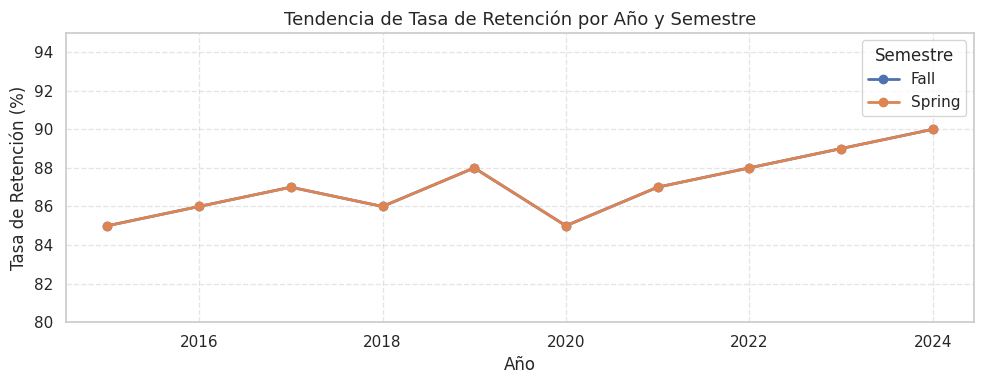


Observación: La retención aumentó de 85% en 2015 a 90% en 2024, mostrando una tendencia positiva sostenida.


In [5]:
# Agrupamos por año y semestre para obtener la retención promedio
ret_trend = df.groupby(['Year', 'Term'])['Retention Rate (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for term, grp in ret_trend.groupby('Term'):
    ax.plot(grp['Year'], grp['Retention Rate (%)'], marker='o', linewidth=2, label=term)

ax.set_title('Tendencia de Tasa de Retención por Año y Semestre', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Tasa de Retención (%)')
ax.set_ylim(80, 95)
ax.legend(title='Semestre')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nObservación: La retención aumentó de 85% en 2015 a 90% en 2024, mostrando una tendencia positiva sostenida.')

### 3.2 Satisfacción Estudiantil por Año

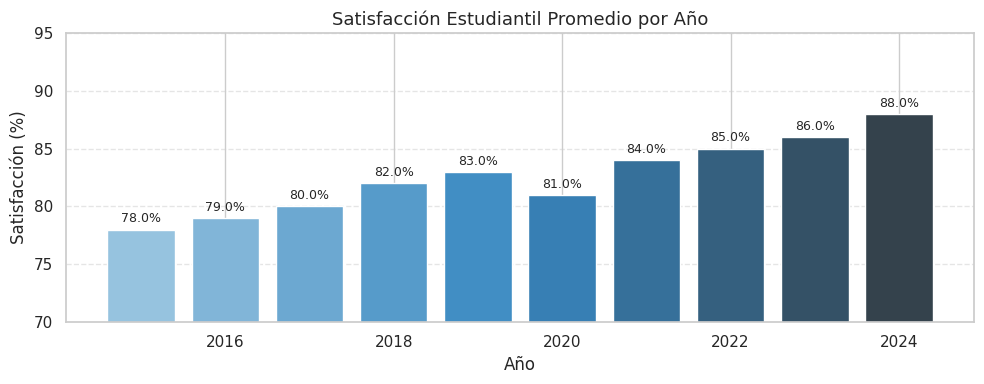


Observación: La satisfacción creció de 78% (2015) a 88% (2024), con una leve caída en 2020 probablemente relacionada con la pandemia.


In [6]:
# Agrupamos por año para obtener la satisfacción promedio
sat_year = df.groupby('Year')['Student Satisfaction (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    sat_year['Year'],
    sat_year['Student Satisfaction (%)'],
    color=sns.color_palette('Blues_d', len(sat_year)),
    edgecolor='white'
)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Satisfacción Estudiantil Promedio por Año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Satisfacción (%)')
ax.set_ylim(70, 95)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nObservación: La satisfacción creció de 78% (2015) a 88% (2024), con una leve caída en 2020 probablemente relacionada con la pandemia.')

### 3.3 Comparación entre Semestres Spring y Fall

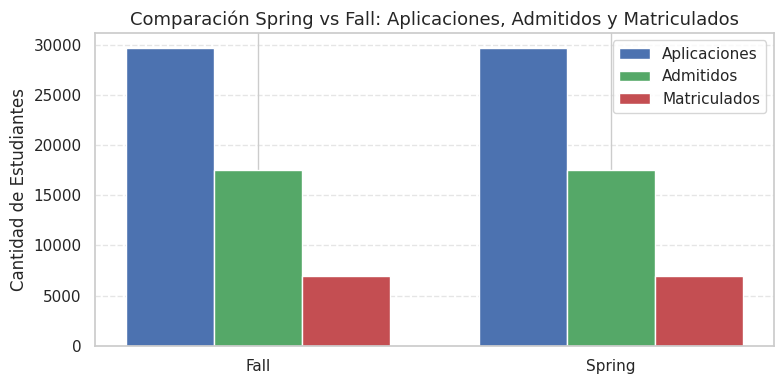


Observación: Ambos semestres presentan cifras prácticamente idénticas, lo que indica una política de admisión estable y simétrica.


In [7]:
# Agrupamos por semestre para comparar aplicaciones, admitidos y matriculados
compare = df.groupby('Term')[['Applications', 'Admitted', 'Enrolled']].sum().reset_index()

x = range(len(compare['Term']))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - width for i in x], compare['Applications'], width, label='Aplicaciones', color='#4C72B0')
ax.bar([i          for i in x], compare['Admitted'],    width, label='Admitidos',    color='#55A868')
ax.bar([i + width for i in x], compare['Enrolled'],     width, label='Matriculados', color='#C44E52')

ax.set_xticks(list(x))
ax.set_xticklabels(compare['Term'])
ax.set_title('Comparación Spring vs Fall: Aplicaciones, Admitidos y Matriculados', fontsize=13)
ax.set_ylabel('Cantidad de Estudiantes')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nObservación: Ambos semestres presentan cifras prácticamente idénticas, lo que indica una política de admisión estable y simétrica.')

### 3.4 Distribución de Matriculados por Departamento (Gráfico adicional)

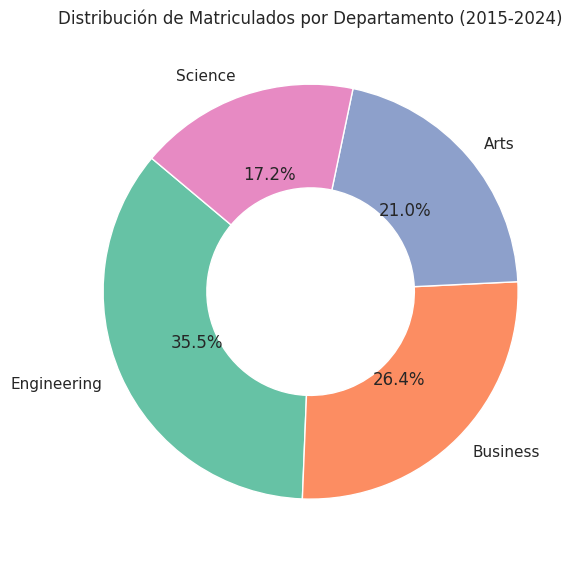


Observación: Engineering es el programa con más matriculados (~37%), seguido de Business (~27%).


In [8]:
# Totales por departamento
dept_cols = ['Engineering Enrolled', 'Business Enrolled', 'Arts Enrolled', 'Science Enrolled']
dept_totals = df[dept_cols].sum()
dept_labels = ['Engineering', 'Business', 'Arts', 'Science']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    dept_totals,
    labels=dept_labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5),
    colors=sns.color_palette('Set2', 4)
)
ax.set_title('Distribución de Matriculados por Departamento (2015-2024)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nObservación: Engineering es el programa con más matriculados (~37%), seguido de Business (~27%).')

## 4. Conclusiones y hallazgos principales

1. **Retención en ascenso:** La tasa de retención creció del 85% al 90% entre 2015 y 2024, reflejando mejoras continuas en los programas de apoyo estudiantil.

2. **Satisfacción creciente:** La satisfacción aumentó de 78% a 88%, con una caída leve en 2020 probablemente asociada al contexto de la pandemia COVID-19.

3. **Equidad entre semestres:** Spring y Fall presentan cifras idénticas, lo que indica una política de admisión estable y equitativa.

4. **Dominio de Engineering:** El programa de Ingeniería concentra la mayor proporción de matriculados (~37%).

5. **Insight accionable:** Se recomienda investigar la caída sostenida en Science (de 130 estudiantes en 2020 a 100 en 2024) e implementar estrategias para atraer más estudiantes a ese programa.